In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin1', encoding_errors='ignore')


### 1. Data Inspection

In [2]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
print(df.isna().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
df.duplicated().sum()

np.int64(0)

### 2. Sales Distribution by Region

In [6]:
region_sales_df = (
    df.groupby('Region', as_index=False)['Sales']
      .sum()
      .sort_values('Sales', ascending=False)
)

display(
    region_sales_df.style
    .format({'Sales':'${:,.0f}'})
    .hide(axis='index')
)

Region,Sales
West,"$725,458"
East,"$678,781"
Central,"$501,240"
South,"$391,722"


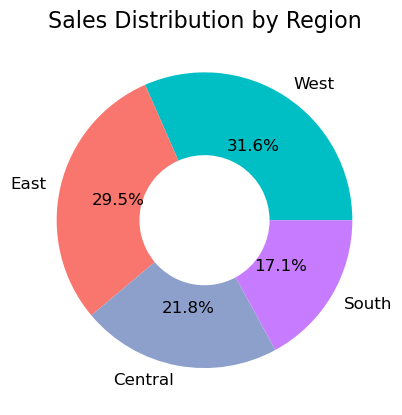

In [7]:
plt.pie(
    region_sales_df['Sales'],                  
    labels=region_sales_df['Region'],          
    autopct='%1.1f%%',
    colors = ['#00BFC4', '#F8766D', '#8DA0CB', '#C77CFF'],
    wedgeprops={'width': 0.56},  # Donut
    textprops={'fontsize': 12}   
)
plt.title("Sales Distribution by Region", fontsize=16)
plt.show()

### 3. Sales and Profit by Category

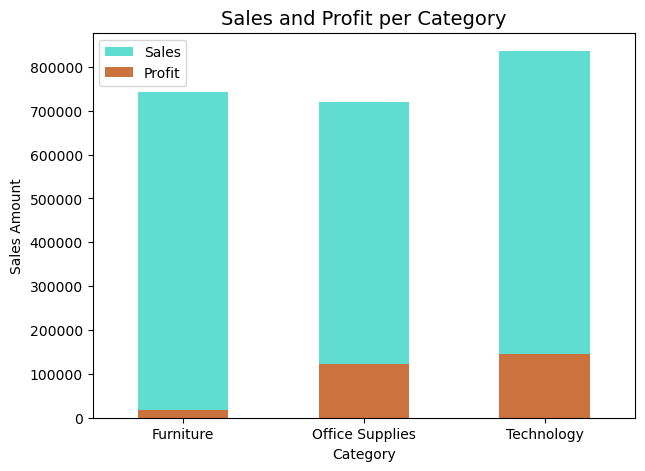

In [8]:
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
plt.figure(figsize=(7,5))

sns.barplot(
    data=category_analysis,
    x='Category',
    y='Sales',
    color="#4df0e0cd",
    label='Sales',
    width=0.5 
)

sns.barplot(
    data=category_analysis,
    x='Category',
    y='Profit',
    color="#e46c26d4",
    label='Profit',
    width=0.5
)

plt.title('Sales and Profit per Category', fontsize=14)
plt.ylabel('Sales Amount')
plt.legend()
plt.show()


### 4. Sub-Category Profit Analysis

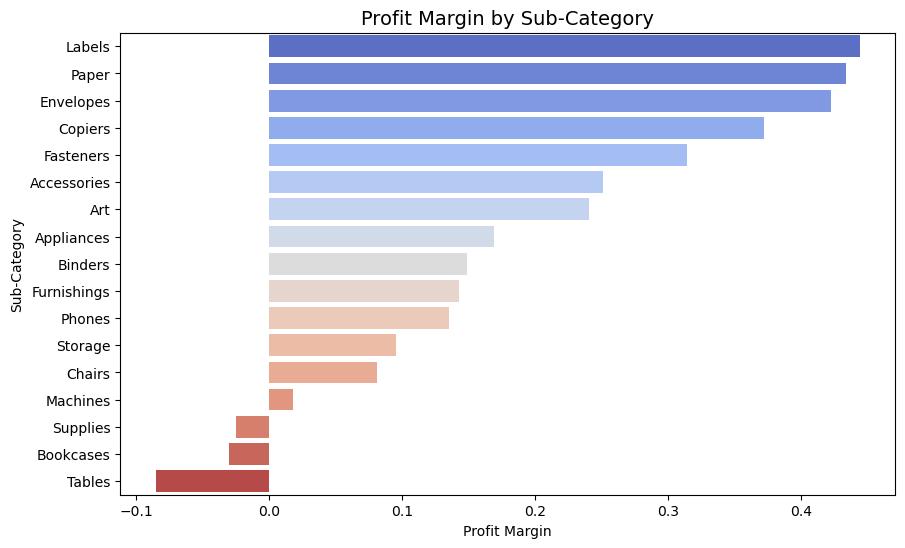

In [9]:
# Product Profitability Analysis 
# 1. Calculate Profit Margin
subcat_sum = df.groupby('Sub-Category')[['Sales', 'Profit']].sum()

subcat_sum['Profit_Margin'] = subcat_sum['Profit'] / subcat_sum['Sales']
subcat_margin = subcat_sum.sort_values('Profit_Margin', ascending=False).reset_index()

# 2. Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    data=subcat_margin,
    x='Profit_Margin',
    y='Sub-Category',
    hue='Sub-Category',
    palette='coolwarm',
    legend=False
)

plt.title("Profit Margin by Sub-Category", fontsize=14)
plt.xlabel("Profit Margin")
plt.show()

### 5. Top 10 Best-Selling Products

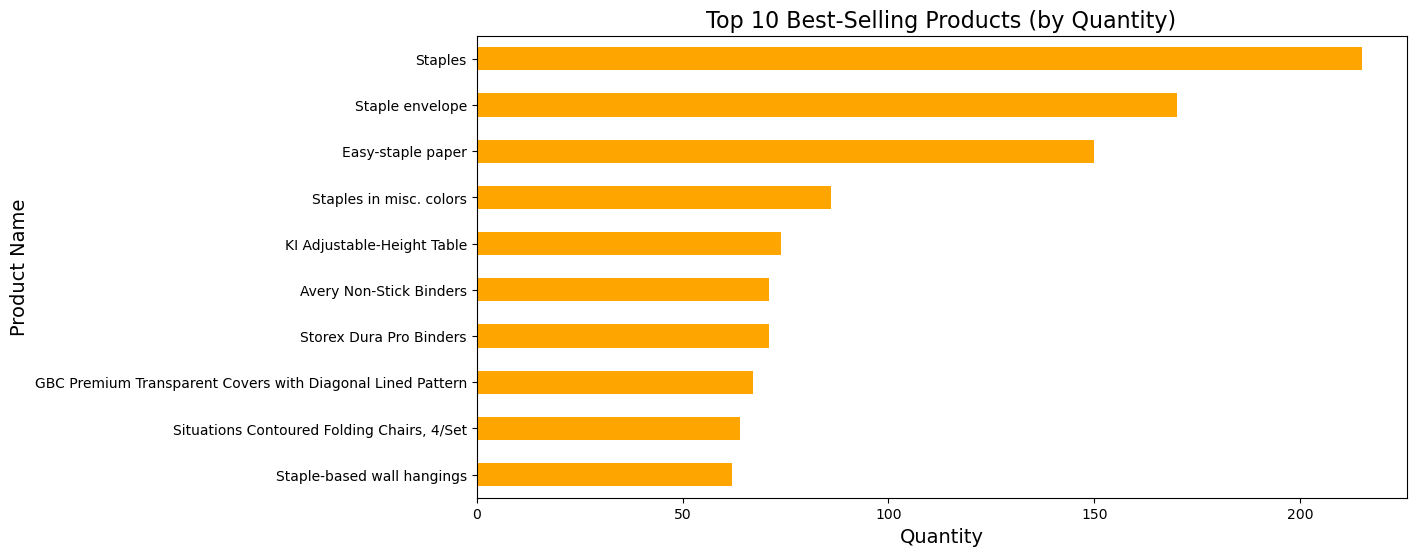

In [10]:
top_products_quantity = (
    df.groupby('Product Name')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products_quantity.plot(kind='barh', color='orange')
plt.title('Top 10 Best-Selling Products (by Quantity)', fontsize=16)
plt.xlabel('Quantity', fontsize=14)
plt.ylabel('Product Name', fontsize=14)
plt.gca().invert_yaxis()
plt.show()


### 6. Monthly Sales Trend

In [11]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year

annual_sales = (
    df.groupby('Year', as_index=False)['Sales']
      .sum()
)

annual_sales.style\
    .format({'Sales':'${:,.0f}'})\
    .hide(axis='index')

Year,Sales
2014,"$484,247"
2015,"$470,533"
2016,"$609,206"
2017,"$733,215"


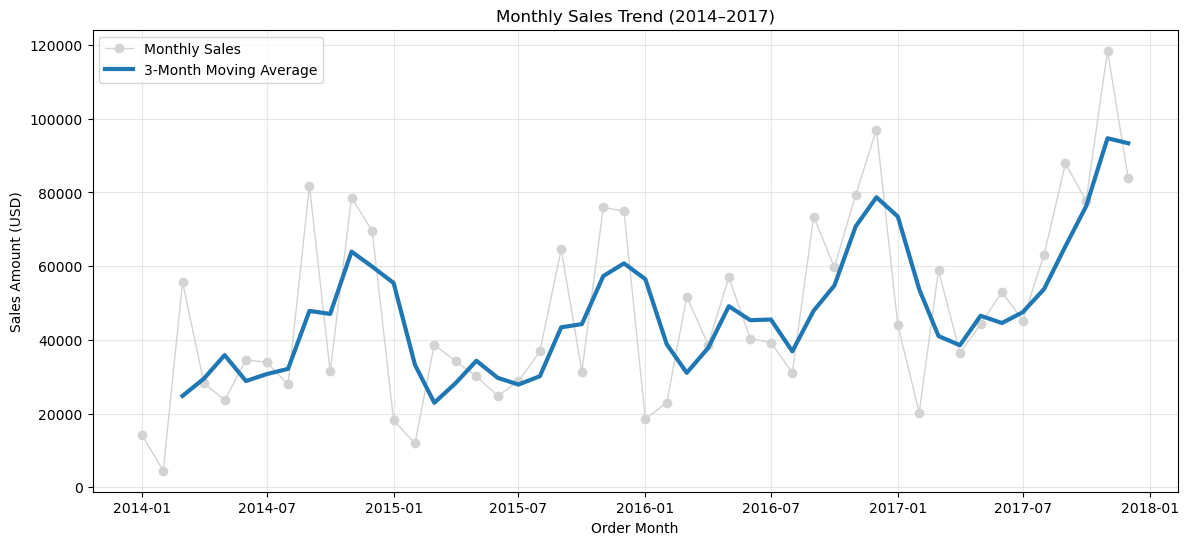

In [ ]:
# Create monthly timestamp
df['Order Month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()

# Monthly sales
monthly_sales = (
    df.groupby('Order Month')['Sales']
      .sum()
      .sort_index()
)

# 3-month moving average (smooth short-term fluctuations)
rolling_mean = monthly_sales.rolling(window=3).mean()

# Plot monthly sales and moving average trend
plt.figure(figsize=(14,6))

# Original monthly sales 
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=1,
    color='lightgray',
    label='Monthly Sales'
)

# Smoothed sales trend
plt.plot(
    rolling_mean.index,
    rolling_mean.values,
    linewidth=3,
    label='3-Month Moving Average'
)

plt.title('Monthly Sales Trend (2014–2017)')
plt.xlabel('Order Month')
plt.ylabel('Sales Amount (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### 7. Seasonal Sales Pattern

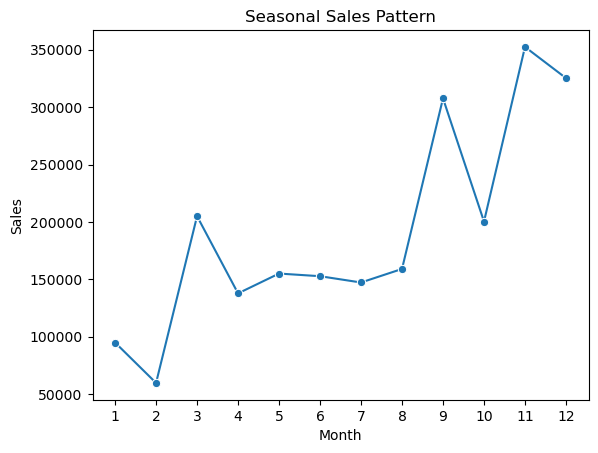

In [13]:
# Seasonal Sales Pattern
df['Order Date'] = pd.to_datetime(df['Order Date'])   # Convert to datetime format
df['Month'] = df['Order Date'].dt.month               # Extract month from order date

month_Sales = (
    df.groupby('Month')['Sales']
      .sum()
      .reset_index()
)

sns.lineplot(data = month_Sales , x = 'Month' , y = 'Sales', marker='o')     
plt.title('Seasonal Sales Pattern')
plt.xticks(range(1, 13))  
plt.show()
